In [1]:
try:
    %load_ext autoreload
    %autoreload 2
    %matplotlib widget
    print('Magic loaded')
except:
    print('No magic')

Magic loaded


In [2]:
from pandas import DataFrame

In [3]:
import sys
sys.path.insert(1,"../")
from pySEA.rayTEM.elements import Lens,Drift,Quadrapole,fix_ray_dims
from pySEA.rayTEM.assemblies import MicroscopeSection
from pySEA.rayTEM.postprocessing import plot2D,plot3D,plotSliceSeries
import numpy as np

In [4]:
# Construct our microscope section: drifts and lenses
elements=[ 	Drift(length=1),
			Lens(strength=3.5,length=.1), 
			Drift(length=1),Quadrapole(strength=.5,length=.1),Drift(length=1.9),
			#Drift(length=3), 
			Lens(strength=3,length=.1), 
			Drift(length=1),Quadrapole(strength=-.2,length=.1),Drift(length=3.9) ]
			#Drift(length=5) ]

section=MicroscopeSection(elements=elements)

Construct our list of rays: starting positions and angles. A minimum of two (is required for auto-detection of image/diffraction planes (one normal, one at an angle, both from the same point) 

In [11]:
r0=np.asarray( [[1,1,0,0],[1,1,-1,-1]] )
r0=fix_ray_dims(r0,["x","y","xt","yt"])

Propagate and 2D plot

diffraction rays (x2) in X: must be finite x, zero y, zero xt and yt
image rays (x2) in X: must be finite xt, zero yt, zero x and y


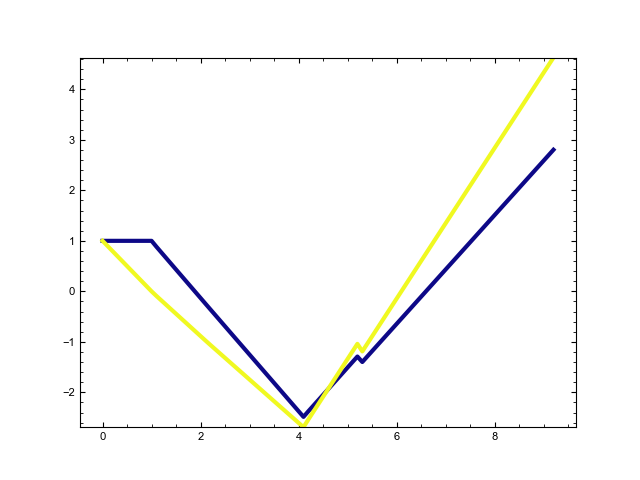

In [12]:
r1=section.propagate_ray(r0)
plot2D(r1)

Alternate list of rays: a whole series of positions and angles should make visualizing the image and diffraction planes easier.

In [13]:
r0=[]
for x in np.arange(-2,3):
	for y in np.arange(-2,3):
		for xt in [-1,0,1]:
			for yt in [-1,0,1]:
				r0.append([x,y,xt,yt])
r0=fix_ray_dims(np.asarray(r0),["x","y","xt","yt"])

Propoagate and 3D plot

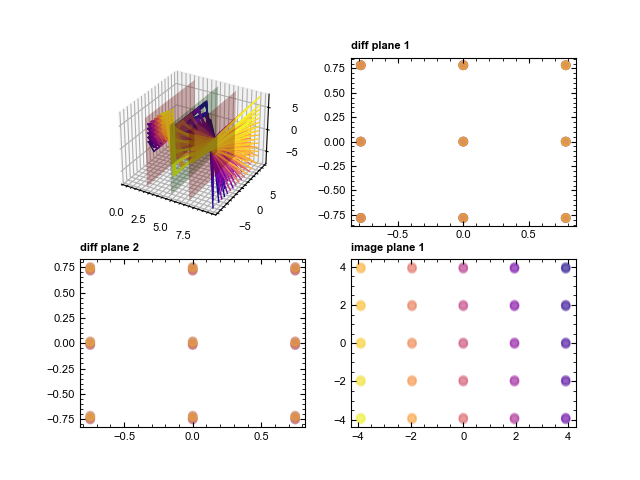

In [14]:
r1=section.propagate_ray(r0)
plot3D(r1)

In [9]:
#plotSliceSeries(r1,20,20)